In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("data/raw/nav_history.csv")

transactions = pd.read_csv("data/raw/investor_transactions.csv")

portfolio = pd.read_csv("data/raw/portfolio_holdings.csv")

performance = pd.read_csv("data/raw/scheme_performance.csv")

fund_master = pd.read_csv("data/raw/fund_master.csv")

In [3]:
nav.head()

,date,nav
0,19-06-2026,202.0761
1,18-06-2026,200.9565
2,17-06-2026,199.8302
3,16-06-2026,198.6152
4,15-06-2026,198.0320


In [5]:
print(nav.columns)

Index(['date', 'nav'], dtype='str')


In [6]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 3105 entries, 0 to 3104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3105 non-null   datetime64[us]
 1   nav     3105 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 48.6 KB


In [7]:
nav.head()

,date,nav
0,2026-06-19,202.0761
1,2026-06-18,200.9565
2,2026-06-17,199.8302
3,2026-06-16,198.6152
4,2026-06-15,198.0320


In [8]:
import pandas as pd

axis = pd.read_csv("data/raw/Axis_Bluechip.csv")
icici = pd.read_csv("data/raw/ICICI_Bluechip.csv")
kotak = pd.read_csv("data/raw/Kotak_Bluechip.csv")
nippon = pd.read_csv("data/raw/Nippon_Large_Cap.csv")
sbi = pd.read_csv("data/raw/SBI_Bluechip.csv")

In [9]:
axis.head()

,date,nav
0,19-06-2026,6195.7815
1,18-06-2026,6194.6520
2,17-06-2026,6193.3504
3,16-06-2026,6191.8120
4,15-06-2026,6187.8223


In [10]:
axis["scheme"] = "Axis Bluechip"
icici["scheme"] = "ICICI Bluechip"
kotak["scheme"] = "Kotak Bluechip"
nippon["scheme"] = "Nippon Large Cap"
sbi["scheme"] = "SBI Bluechip"

In [11]:
nav = pd.concat(
    [axis, icici, kotak, nippon, sbi],
    ignore_index=True
)

nav.head()

,date,nav,scheme
0,19-06-2026,6195.7815,Axis Bluechip
1,18-06-2026,6194.6520,Axis Bluechip
2,17-06-2026,6193.3504,Axis Bluechip
3,16-06-2026,6191.8120,Axis Bluechip
4,15-06-2026,6187.8223,Axis Bluechip


In [12]:
nav["date"] = pd.to_datetime(
    nav["date"],
    dayfirst=True
)

nav = nav.sort_values(
    ["scheme", "date"]
)

nav.head()

,date,nav,scheme
3578,2012-12-31,23.9920,Axis Bluechip
3577,2013-01-01,23.9979,Axis Bluechip
3576,2013-01-02,24.0036,Axis Bluechip
3575,2013-01-03,24.0092,Axis Bluechip
3574,2013-01-04,24.0147,Axis Bluechip


In [13]:
nav["daily_return"] = (
    nav.groupby("scheme")["nav"]
       .pct_change()
)

nav.head()

,date,nav,scheme,daily_return
3578,2012-12-31,23.9920,Axis Bluechip,NaN
3577,2013-01-01,23.9979,Axis Bluechip,0.000246
3576,2013-01-02,24.0036,Axis Bluechip,0.000238
3575,2013-01-03,24.0092,Axis Bluechip,0.000233
3574,2013-01-04,24.0147,Axis Bluechip,0.000229


In [14]:
results = []

for scheme, df in nav.groupby("scheme"):

    returns = df["daily_return"].dropna()

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    results.append(
        [scheme, var95, cvar95]
    )

var_df = pd.DataFrame(
    results,
    columns=[
        "Scheme",
        "VaR95",
        "CVaR95"
    ]
)

var_df

,Scheme,VaR95,CVaR95
0,Axis Bluechip,0.000059,-0.000205
1,ICICI Bluechip,-0.014598,-0.028619
2,Kotak Bluechip,-0.014235,-0.023849
3,Nippon Large Cap,-0.015860,-0.024661
4,SBI Bluechip,-0.001019,-0.008438


In [15]:
import os

os.makedirs(
    "reports/advanced",
    exist_ok=True
)

var_df.to_csv(
    "reports/advanced/var_cvar_report.csv",
    index=False
)

print("CSV Saved Successfully!")

CSV Saved Successfully!


In [16]:
import numpy as np

# Calculate 90-day Rolling Sharpe Ratio
nav["rolling_sharpe"] = (
    nav.groupby("scheme")["daily_return"]
       .transform(
           lambda x: (
               x.rolling(90).mean() /
               x.rolling(90).std()
           ) * np.sqrt(252)
       )
)

nav.head()

,date,nav,scheme,daily_return,rolling_sharpe
3578,2012-12-31,23.9920,Axis Bluechip,NaN,NaN
3577,2013-01-01,23.9979,Axis Bluechip,0.000246,NaN
3576,2013-01-02,24.0036,Axis Bluechip,0.000238,NaN
3575,2013-01-03,24.0092,Axis Bluechip,0.000233,NaN
3574,2013-01-04,24.0147,Axis Bluechip,0.000229,NaN


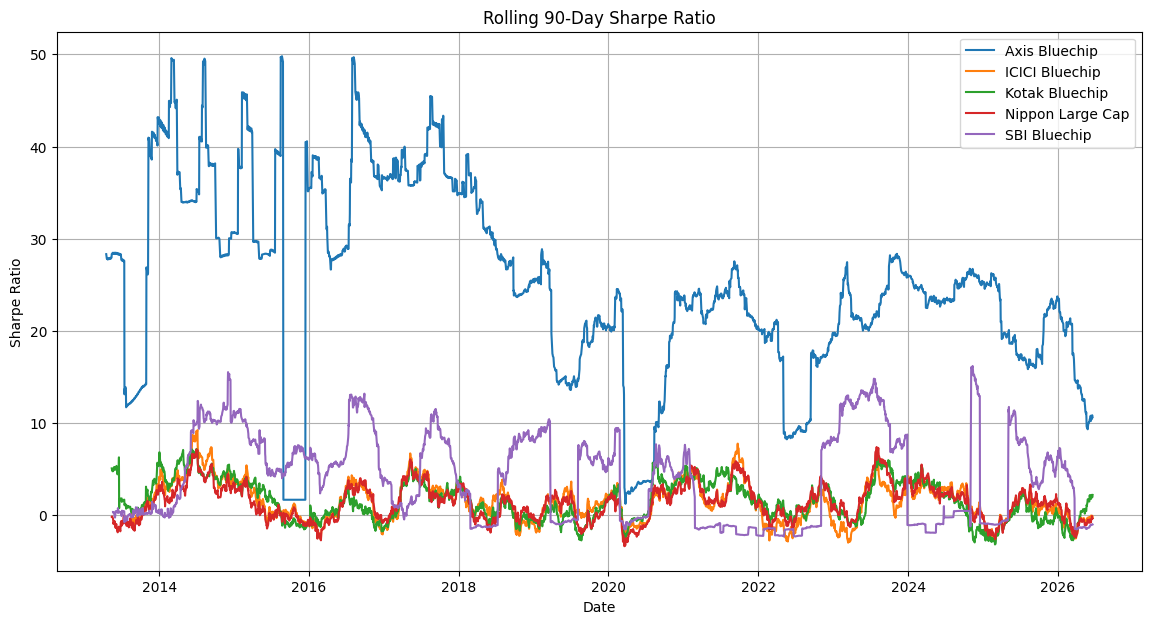

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for scheme in nav["scheme"].unique():
    
    df = nav[nav["scheme"] == scheme]
    
    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

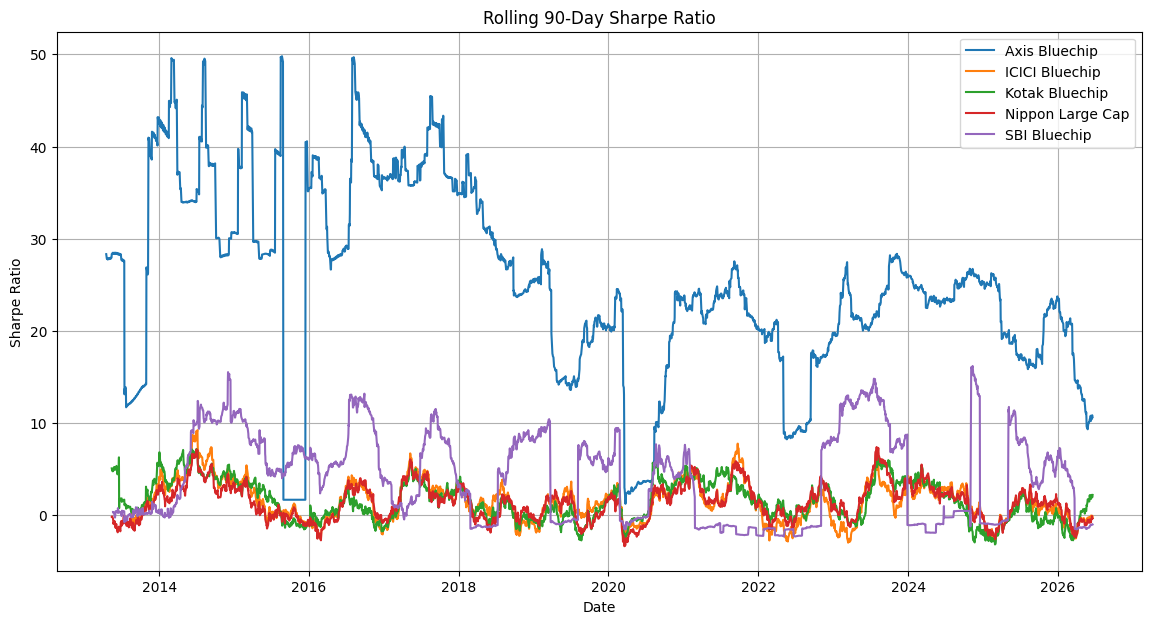

Rolling Sharpe chart saved successfully!


In [18]:
import os

os.makedirs(
    "reports/advanced",
    exist_ok=True
)

plt.figure(figsize=(14,7))

for scheme in nav["scheme"].unique():
    
    df = nav[nav["scheme"] == scheme]
    
    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "reports/advanced/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Rolling Sharpe chart saved successfully!")

In [19]:
transactions = pd.read_csv("data/raw/investor_transactions.csv")

transactions.head()

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
0,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
1,1,125497,SIP,5000,10-01-2026,VERIFIED,Andhra Pradesh
2,2,119551,Lumpsum,10000,15-02-2026,VERIFIED,Telangana
3,3,120503,Redemption,2000,20-03-2026,PENDING,Karnataka
4,4,118632,SIP,3000,25-04-2026,VERIFIED,Tamil Nadu


In [20]:
transactions.columns

Index(['investor_id', 'fund_code', 'transaction_type', 'amount',
       'transaction_date', 'kyc_status', 'state'],
      dtype='str')

In [22]:
transactions.head(10)

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
0,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
1,1,125497,SIP,5000,10-01-2026,VERIFIED,Andhra Pradesh
2,2,119551,Lumpsum,10000,15-02-2026,VERIFIED,Telangana
3,3,120503,Redemption,2000,20-03-2026,PENDING,Karnataka
4,4,118632,SIP,3000,25-04-2026,VERIFIED,Tamil Nadu
5,5,120841,Lumpsum,15000,30-05-2026,REJECTED,Kerala
6,6,119092,SIP,2500,05-06-2026,VERIFIED,Maharashtra
7,7,125497,Redemption,1000,10-06-2026,PENDING,Delhi
8,8,119551,SIP,4000,15-06-2026,VERIFIED,Gujarat
9,9,120503,Lumpsum,12000,20-06-2026,VERIFIED,Punjab


In [23]:
transactions.tail(10)

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
16,16,118632,Lumpsum,22000,08-07-2026,PENDING,West Bengal
17,17,120841,SIP,3500,10-07-2026,VERIFIED,Chhattisgarh
18,18,119092,Redemption,2000,12-07-2026,VERIFIED,Jharkhand
19,19,125497,Lumpsum,25000,15-07-2026,VERIFIED,Goa
20,20,119551,SIP,4500,18-07-2026,PENDING,Andhra Pradesh
21,21,120503,SIP,3000,20-07-2026,VERIFIED,Telangana
22,22,118632,Redemption,1500,22-07-2026,VERIFIED,Karnataka
23,23,120841,Lumpsum,17000,25-07-2026,VERIFIED,Tamil Nadu
24,24,119092,SIP,2800,28-07-2026,PENDING,Kerala
25,25,125497,SIP,5200,30-07-2026,VERIFIED,Maharashtra


In [24]:
transactions[
    transactions["transaction_date"] == "transaction_date"
]

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
0,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state


In [25]:
transactions = transactions[
    transactions["transaction_date"] != "transaction_date"
]

In [26]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

In [27]:
transactions["transaction_date"].isna().sum()

np.int64(16)

In [28]:
transactions[
    transactions["transaction_date"].isna()
]

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
2,2,119551,Lumpsum,10000,NaT,VERIFIED,Telangana
3,3,120503,Redemption,2000,NaT,PENDING,Karnataka
4,4,118632,SIP,3000,NaT,VERIFIED,Tamil Nadu
5,5,120841,Lumpsum,15000,NaT,REJECTED,Kerala
8,8,119551,SIP,4000,NaT,VERIFIED,Gujarat
9,9,120503,Lumpsum,12000,NaT,VERIFIED,Punjab
10,10,118632,SIP,3500,NaT,VERIFIED,Odisha
11,11,120841,SIP,4500,NaT,VERIFIED,Bihar
12,12,119092,Lumpsum,18000,NaT,PENDING,Assam
19,19,125497,Lumpsum,25000,NaT,VERIFIED,Goa


In [29]:
transactions.head()

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
1,1,125497,SIP,5000,2026-10-01,VERIFIED,Andhra Pradesh
2,2,119551,Lumpsum,10000,NaT,VERIFIED,Telangana
3,3,120503,Redemption,2000,NaT,PENDING,Karnataka
4,4,118632,SIP,3000,NaT,VERIFIED,Tamil Nadu
5,5,120841,Lumpsum,15000,NaT,REJECTED,Kerala


In [30]:
import pandas as pd

temp = pd.read_csv("data/raw/investor_transactions.csv")

temp.head(10)

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
0,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
1,1,125497,SIP,5000,10-01-2026,VERIFIED,Andhra Pradesh
2,2,119551,Lumpsum,10000,15-02-2026,VERIFIED,Telangana
3,3,120503,Redemption,2000,20-03-2026,PENDING,Karnataka
4,4,118632,SIP,3000,25-04-2026,VERIFIED,Tamil Nadu
5,5,120841,Lumpsum,15000,30-05-2026,REJECTED,Kerala
6,6,119092,SIP,2500,05-06-2026,VERIFIED,Maharashtra
7,7,125497,Redemption,1000,10-06-2026,PENDING,Delhi
8,8,119551,SIP,4000,15-06-2026,VERIFIED,Gujarat
9,9,120503,Lumpsum,12000,20-06-2026,VERIFIED,Punjab


In [31]:
temp["transaction_date"]

0     transaction_date
1           10-01-2026
2           15-02-2026
3           20-03-2026
4           25-04-2026
5           30-05-2026
6           05-06-2026
7           10-06-2026
8           15-06-2026
9           20-06-2026
10          22-06-2026
11          25-06-2026
12          28-06-2026
13          01-07-2026
14          03-07-2026
15          05-07-2026
16          08-07-2026
17          10-07-2026
18          12-07-2026
19          15-07-2026
20          18-07-2026
21          20-07-2026
22          22-07-2026
23          25-07-2026
24          28-07-2026
25          30-07-2026
Name: transaction_date, dtype: str

In [32]:
temp["transaction_date"].head(20)

0     transaction_date
1           10-01-2026
2           15-02-2026
3           20-03-2026
4           25-04-2026
5           30-05-2026
6           05-06-2026
7           10-06-2026
8           15-06-2026
9           20-06-2026
10          22-06-2026
11          25-06-2026
12          28-06-2026
13          01-07-2026
14          03-07-2026
15          05-07-2026
16          08-07-2026
17          10-07-2026
18          12-07-2026
19          15-07-2026
Name: transaction_date, dtype: str

In [34]:
import pandas as pd

transactions = pd.read_csv("data/raw/investor_transactions.csv")

print(transactions.head(10))

   investor_id  fund_code  transaction_type  amount  transaction_date  \
0  investor_id  fund_code  transaction_type  amount  transaction_date   
1            1     125497               SIP    5000        10-01-2026   
2            2     119551           Lumpsum   10000        15-02-2026   
3            3     120503        Redemption    2000        20-03-2026   
4            4     118632               SIP    3000        25-04-2026   
5            5     120841           Lumpsum   15000        30-05-2026   
6            6     119092               SIP    2500        05-06-2026   
7            7     125497        Redemption    1000        10-06-2026   
8            8     119551               SIP    4000        15-06-2026   
9            9     120503           Lumpsum   12000        20-06-2026   

   kyc_status           state  
0  kyc_status           state  
1    VERIFIED  Andhra Pradesh  
2    VERIFIED       Telangana  
3     PENDING       Karnataka  
4    VERIFIED      Tamil Nadu  
5   

In [35]:
transactions[
    transactions["transaction_date"] == "transaction_date"
]

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
0,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state


In [36]:
transactions = transactions[
    transactions["transaction_date"] != "transaction_date"
]

In [37]:
print(transactions["transaction_date"].head(20).tolist())

['10-01-2026', '15-02-2026', '20-03-2026', '25-04-2026', '30-05-2026', '05-06-2026', '10-06-2026', '15-06-2026', '20-06-2026', '22-06-2026', '25-06-2026', '28-06-2026', '01-07-2026', '03-07-2026', '05-07-2026', '08-07-2026', '10-07-2026', '12-07-2026', '15-07-2026', '18-07-2026']


In [38]:
import pandas as pd

transactions = pd.read_csv("data/raw/investor_transactions.csv")

In [40]:
transactions = pd.read_csv("data/raw/investor_transactions.csv", dtype=str)

transactions[
    transactions["transaction_date"] == "transaction_date"
]

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state
0,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state


In [41]:
transactions.index[
    transactions["transaction_date"] == "transaction_date"
].tolist()

[0]

In [42]:
transactions = transactions[
    transactions["transaction_date"] != "transaction_date"
]

In [43]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    format="%d-%m-%Y"
)

In [44]:
transactions = pd.read_csv("data/raw/investor_transactions.csv", dtype=str)

for i, value in enumerate(transactions["transaction_date"]):
    try:
        pd.to_datetime(value, format="%d-%m-%Y")
    except Exception:
        print("Row:", i, "Value:", value)

Row: 0 Value: transaction_date


In [46]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   investor_id       26 non-null     str  
 1   fund_code         26 non-null     str  
 2   transaction_type  26 non-null     str  
 3   amount            26 non-null     str  
 4   transaction_date  26 non-null     str  
 5   kyc_status        26 non-null     str  
 6   state             26 non-null     str  
dtypes: str(7)
memory usage: 1.6 KB


In [47]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [48]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   investor_id       26 non-null     str           
 1   fund_code         26 non-null     str           
 2   transaction_type  26 non-null     str           
 3   amount            26 non-null     str           
 4   transaction_date  25 non-null     datetime64[us]
 5   kyc_status        26 non-null     str           
 6   state             26 non-null     str           
dtypes: datetime64[us](1), str(6)
memory usage: 1.6 KB


In [49]:
print(transactions["transaction_date"].dtype)

datetime64[us]


In [50]:
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

transactions.head()

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state,cohort_year
0,investor_id,fund_code,transaction_type,amount,NaT,kyc_status,state,NaN
1,1,125497,SIP,5000,2026-01-10,VERIFIED,Andhra Pradesh,2026.0
2,2,119551,Lumpsum,10000,2026-02-15,VERIFIED,Telangana,2026.0
3,3,120503,Redemption,2000,2026-03-20,PENDING,Karnataka,2026.0
4,4,118632,SIP,3000,2026-04-25,VERIFIED,Tamil Nadu,2026.0


In [51]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   investor_id       26 non-null     str           
 1   fund_code         26 non-null     str           
 2   transaction_type  26 non-null     str           
 3   amount            26 non-null     str           
 4   transaction_date  25 non-null     datetime64[us]
 5   kyc_status        26 non-null     str           
 6   state             26 non-null     str           
 7   cohort_year       25 non-null     float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 1.8 KB


In [52]:
print(transactions["transaction_date"].dtype)

datetime64[us]


In [53]:
# First transaction date for each investor
first_txn = transactions.groupby("investor_id")["transaction_date"].min()

# Create cohort year
transactions["cohort_year"] = transactions["investor_id"].map(first_txn.dt.year)

transactions.head()

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state,cohort_year
0,investor_id,fund_code,transaction_type,amount,NaT,kyc_status,state,NaN
1,1,125497,SIP,5000,2026-01-10,VERIFIED,Andhra Pradesh,2026.0
2,2,119551,Lumpsum,10000,2026-02-15,VERIFIED,Telangana,2026.0
3,3,120503,Redemption,2000,2026-03-20,PENDING,Karnataka,2026.0
4,4,118632,SIP,3000,2026-04-25,VERIFIED,Tamil Nadu,2026.0


In [54]:
transactions[["investor_id", "transaction_date", "cohort_year"]].head(10)

,investor_id,transaction_date,cohort_year
0,investor_id,NaT,NaN
1,1,2026-01-10,2026.0
2,2,2026-02-15,2026.0
3,3,2026-03-20,2026.0
4,4,2026-04-25,2026.0
5,5,2026-05-30,2026.0
6,6,2026-06-05,2026.0
7,7,2026-06-10,2026.0
8,8,2026-06-15,2026.0
9,9,2026-06-20,2026.0


In [55]:
print(transactions["transaction_date"].dtype)

print(
    transactions.groupby("investor_id")["transaction_date"].min().dtype
)

datetime64[us]
datetime64[us]


In [56]:
transactions.groupby("investor_id")["transaction_date"].transform("min").dt.year

0        NaN
1     2026.0
2     2026.0
3     2026.0
4     2026.0
5     2026.0
6     2026.0
7     2026.0
8     2026.0
9     2026.0
10    2026.0
11    2026.0
12    2026.0
13    2026.0
14    2026.0
15    2026.0
16    2026.0
17    2026.0
18    2026.0
19    2026.0
20    2026.0
21    2026.0
22    2026.0
23    2026.0
24    2026.0
25    2026.0
Name: transaction_date, dtype: float64

In [57]:
first_txn = transactions.groupby("investor_id")["transaction_date"].min()
transactions["cohort_year"] = transactions["investor_id"].map(first_txn.dt.year)

In [58]:
# Convert amount to numeric
transactions["amount"] = pd.to_numeric(transactions["amount"])

# Filter SIP transactions
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

avg_sip = (
    sip.groupby("cohort_year")["amount"]
       .mean()
       .reset_index()
)

avg_sip.rename(
    columns={"amount": "Average SIP Amount"},
    inplace=True
)

avg_sip

ValueError: Unable to parse string "amount" at position 0

In [59]:
transactions.head(10)

,investor_id,fund_code,transaction_type,amount,transaction_date,kyc_status,state,cohort_year
0,investor_id,fund_code,transaction_type,amount,NaT,kyc_status,state,NaN
1,1,125497,SIP,5000,2026-01-10,VERIFIED,Andhra Pradesh,2026.0
2,2,119551,Lumpsum,10000,2026-02-15,VERIFIED,Telangana,2026.0
3,3,120503,Redemption,2000,2026-03-20,PENDING,Karnataka,2026.0
4,4,118632,SIP,3000,2026-04-25,VERIFIED,Tamil Nadu,2026.0
5,5,120841,Lumpsum,15000,2026-05-30,REJECTED,Kerala,2026.0
6,6,119092,SIP,2500,2026-06-05,VERIFIED,Maharashtra,2026.0
7,7,125497,Redemption,1000,2026-06-10,PENDING,Delhi,2026.0
8,8,119551,SIP,4000,2026-06-15,VERIFIED,Gujarat,2026.0
9,9,120503,Lumpsum,12000,2026-06-20,VERIFIED,Punjab,2026.0


In [60]:
transactions = transactions[
    transactions["amount"] != "amount"
]

In [61]:
transactions["amount"] = pd.to_numeric(
    transactions["amount"],
    errors="coerce"
)

In [62]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   investor_id       25 non-null     str           
 1   fund_code         25 non-null     str           
 2   transaction_type  25 non-null     str           
 3   amount            25 non-null     int64         
 4   transaction_date  25 non-null     datetime64[us]
 5   kyc_status        25 non-null     str           
 6   state             25 non-null     str           
 7   cohort_year       25 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 1.7 KB


In [63]:
print(transactions.head())

  investor_id fund_code transaction_type  amount transaction_date kyc_status  \
1           1    125497              SIP    5000       2026-01-10   VERIFIED   
2           2    119551          Lumpsum   10000       2026-02-15   VERIFIED   
3           3    120503       Redemption    2000       2026-03-20    PENDING   
4           4    118632              SIP    3000       2026-04-25   VERIFIED   
5           5    120841          Lumpsum   15000       2026-05-30   REJECTED   

            state  cohort_year  
1  Andhra Pradesh       2026.0  
2       Telangana       2026.0  
3       Karnataka       2026.0  
4      Tamil Nadu       2026.0  
5          Kerala       2026.0  


In [64]:
print(transactions.iloc[0])

investor_id                           1
fund_code                        125497
transaction_type                    SIP
amount                             5000
transaction_date    2026-01-10 00:00:00
kyc_status                     VERIFIED
state                    Andhra Pradesh
cohort_year                      2026.0
Name: 1, dtype: object


In [65]:
transactions = pd.read_csv("data/raw/investor_transactions.csv", dtype=str)

# Remove any duplicated header rows
transactions = transactions[
    transactions["investor_id"] != "investor_id"
].copy()

# Convert columns
transactions["amount"] = pd.to_numeric(transactions["amount"], errors="coerce")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   investor_id       25 non-null     str           
 1   fund_code         25 non-null     str           
 2   transaction_type  25 non-null     str           
 3   amount            25 non-null     int64         
 4   transaction_date  25 non-null     datetime64[us]
 5   kyc_status        25 non-null     str           
 6   state             25 non-null     str           
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 1.5 KB


In [66]:
import pandas as pd

# Read as strings
transactions = pd.read_csv("data/raw/investor_transactions.csv", dtype=str)

# Remove duplicate header rows (if any)
transactions = transactions[
    transactions["investor_id"] != "investor_id"
].copy()

# Convert amount to numeric
transactions["amount"] = pd.to_numeric(
    transactions["amount"],
    errors="coerce"
)

# Convert transaction_date to datetime
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Remove rows with invalid amount or date
transactions = transactions.dropna(
    subset=["amount", "transaction_date"]
)

print(transactions.info())
print(transactions.head())

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   investor_id       25 non-null     str           
 1   fund_code         25 non-null     str           
 2   transaction_type  25 non-null     str           
 3   amount            25 non-null     int64         
 4   transaction_date  25 non-null     datetime64[us]
 5   kyc_status        25 non-null     str           
 6   state             25 non-null     str           
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 1.5 KB
None
  investor_id fund_code transaction_type  amount transaction_date kyc_status  \
1           1    125497              SIP    5000       2026-01-10   VERIFIED   
2           2    119551          Lumpsum   10000       2026-02-15   VERIFIED   
3           3    120503       Redemption    2000       2026-03-20    PENDING   
4           4    118632          

In [67]:
# First transaction date for each investor
first_txn = transactions.groupby("investor_id")["transaction_date"].min()

# Map first transaction year back to each row
transactions["cohort_year"] = transactions["investor_id"].map(
    first_txn.dt.year
)

transactions[
    ["investor_id", "transaction_date", "cohort_year"]
].head()

,investor_id,transaction_date,cohort_year
1,1,2026-01-10,2026
2,2,2026-02-15,2026
3,3,2026-03-20,2026
4,4,2026-04-25,2026
5,5,2026-05-30,2026


In [68]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

avg_sip = (
    sip.groupby("cohort_year")["amount"]
       .mean()
       .reset_index(name="Average SIP Amount")
)

avg_sip

,cohort_year,Average SIP Amount
0,2026,4038.461538


In [69]:
performance = pd.read_csv("data/raw/scheme_performance.csv")

performance

,scheme_code,return_1y,return_3y,return_5y,expense_ratio
0,125497,12.5,18.2,20.1,1.2
1,119551,10.3,15.8,18.5,0.9
2,120503,11.7,17.0,19.3,1.1
3,128930,13.1,19.4,21.0,1.3
4,118834,9.5,14.0,17.5,0.7


In [70]:
performance.columns

Index(['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio'], dtype='str')

In [71]:
performance["risk_grade"] = [
    "Moderate",
    "Low",
    "Moderate",
    "High",
    "Low"
]

In [72]:
latest_sharpe = (
    nav.groupby("scheme")["rolling_sharpe"]
       .last()
       .reset_index()
)

latest_sharpe.columns = [
    "scheme_name",
    "Sharpe Ratio"
]

latest_sharpe

,scheme_name,Sharpe Ratio
0,Axis Bluechip,10.627863
1,ICICI Bluechip,-0.232797
2,Kotak Bluechip,2.199275
3,Nippon Large Cap,-0.354981
4,SBI Bluechip,-1.015560


In [74]:
performance.columns

Index(['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio',
       'risk_grade'],
      dtype='str')

In [75]:
performance.head()

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,risk_grade
0,125497,12.5,18.2,20.1,1.2,Moderate
1,119551,10.3,15.8,18.5,0.9,Low
2,120503,11.7,17.0,19.3,1.1,Moderate
3,128930,13.1,19.4,21.0,1.3,High
4,118834,9.5,14.0,17.5,0.7,Low


In [78]:
print(performance.columns)

Index(['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio',
       'risk_grade'],
      dtype='str')


In [79]:
print(fund_master.columns)

Index(['scheme_code', 'scheme_name', 'fund_house', 'scheme_type',
       'scheme_category'],
      dtype='str')


In [80]:
print(latest_sharpe.head())

        scheme_name  Sharpe Ratio
0     Axis Bluechip     10.627863
1    ICICI Bluechip     -0.232797
2    Kotak Bluechip      2.199275
3  Nippon Large Cap     -0.354981
4      SBI Bluechip     -1.015560


In [82]:
print(performance.columns.tolist())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio', 'risk_grade']


In [83]:
print(fund_master.columns.tolist())

['scheme_code', 'scheme_name', 'fund_house', 'scheme_type', 'scheme_category']


In [84]:
print(latest_sharpe.head())

        scheme_name  Sharpe Ratio
0     Axis Bluechip     10.627863
1    ICICI Bluechip     -0.232797
2    Kotak Bluechip      2.199275
3  Nippon Large Cap     -0.354981
4      SBI Bluechip     -1.015560


In [85]:
print(performance.columns.tolist())

print(fund_master.columns.tolist())

print(latest_sharpe.head())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio', 'risk_grade']
['scheme_code', 'scheme_name', 'fund_house', 'scheme_type', 'scheme_category']
        scheme_name  Sharpe Ratio
0     Axis Bluechip     10.627863
1    ICICI Bluechip     -0.232797
2    Kotak Bluechip      2.199275
3  Nippon Large Cap     -0.354981
4      SBI Bluechip     -1.015560


In [86]:
performance = performance.merge(
    fund_master[["scheme_code", "scheme_name"]],
    on="scheme_code",
    how="left"
)

performance.head()

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,risk_grade,scheme_name
0,125497,12.5,18.2,20.1,1.2,Moderate,SBI Bluechip Fund
1,119551,10.3,15.8,18.5,0.9,Low,Axis Bluechip Fund
2,120503,11.7,17.0,19.3,1.1,Moderate,ICICI Prudential Bluechip Fund
3,128930,13.1,19.4,21.0,1.3,High,Kotak Bluechip Fund
4,118834,9.5,14.0,17.5,0.7,Low,Nippon India Large Cap Fund


In [87]:
print(performance.columns)

Index(['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio',
       'risk_grade', 'scheme_name'],
      dtype='str')


In [88]:
funds = performance.merge(
    latest_sharpe,
    on="scheme_name",
    how="left"
)

funds.head()

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,risk_grade,scheme_name,Sharpe Ratio
0,125497,12.5,18.2,20.1,1.2,Moderate,SBI Bluechip Fund,NaN
1,119551,10.3,15.8,18.5,0.9,Low,Axis Bluechip Fund,NaN
2,120503,11.7,17.0,19.3,1.1,Moderate,ICICI Prudential Bluechip Fund,NaN
3,128930,13.1,19.4,21.0,1.3,High,Kotak Bluechip Fund,NaN
4,118834,9.5,14.0,17.5,0.7,Low,Nippon India Large Cap Fund,NaN


In [89]:
funds

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,risk_grade,scheme_name,Sharpe Ratio
0,125497,12.5,18.2,20.1,1.2,Moderate,SBI Bluechip Fund,NaN
1,119551,10.3,15.8,18.5,0.9,Low,Axis Bluechip Fund,NaN
2,120503,11.7,17.0,19.3,1.1,Moderate,ICICI Prudential Bluechip Fund,NaN
3,128930,13.1,19.4,21.0,1.3,High,Kotak Bluechip Fund,NaN
4,118834,9.5,14.0,17.5,0.7,Low,Nippon India Large Cap Fund,NaN


In [90]:
print(fund_master["scheme_name"].tolist())

['SBI Bluechip Fund', 'Axis Bluechip Fund', 'ICICI Prudential Bluechip Fund', 'Kotak Bluechip Fund', 'Nippon India Large Cap Fund']


In [91]:
print(latest_sharpe["scheme_name"].tolist())

['Axis Bluechip', 'ICICI Bluechip', 'Kotak Bluechip', 'Nippon Large Cap', 'SBI Bluechip']


In [93]:
performance = performance.merge(
    fund_master[["scheme_code", "scheme_name"]],
    on="scheme_code",
    how="left"
)

print(performance.columns.tolist())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio', 'risk_grade', 'scheme_name_x', 'scheme_name_y', 'scheme_name']


In [95]:
print(performance.columns.tolist())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio', 'risk_grade', 'scheme_name_x', 'scheme_name_y', 'scheme_name']


In [96]:
import pandas as pd

# Reload fresh data
performance = pd.read_csv("data/raw/scheme_performance.csv")
fund_master = pd.read_csv("data/raw/fund_master.csv")

print(performance.columns.tolist())
print(fund_master.columns.tolist())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio']
['scheme_code', 'scheme_name', 'fund_house', 'scheme_type', 'scheme_category']


In [97]:
performance = performance.merge(
    fund_master[["scheme_code", "scheme_name"]],
    on="scheme_code",
    how="left"
)

print(performance.columns.tolist())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio', 'scheme_name']


In [98]:
funds = performance.merge(
    latest_sharpe,
    on="scheme_name",
    how="left"
)

funds.head()

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,scheme_name,Sharpe Ratio
0,125497,12.5,18.2,20.1,1.2,SBI Bluechip Fund,NaN
1,119551,10.3,15.8,18.5,0.9,Axis Bluechip Fund,NaN
2,120503,11.7,17.0,19.3,1.1,ICICI Prudential Bluechip Fund,NaN
3,128930,13.1,19.4,21.0,1.3,Kotak Bluechip Fund,NaN
4,118834,9.5,14.0,17.5,0.7,Nippon India Large Cap Fund,NaN


In [99]:
print(performance.columns.tolist())

['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio', 'scheme_name']


In [100]:
import os

os.path.exists("data/raw/portfolio_holdings.csv")

True

In [101]:
portfolio = pd.read_csv("data/raw/portfolio_holdings.csv")

portfolio.head()

,fund_name,sector,weight
0,SBI Small Cap,IT,18
1,SBI Small Cap,Banking,22
2,SBI Small Cap,Healthcare,15
3,ICICI Bluechip,IT,20
4,ICICI Bluechip,Banking,25


In [102]:
portfolio.columns.tolist()

['fund_name', 'sector', 'weight']

In [103]:
import os
print(os.path.exists("data/raw/portfolio_holdings.csv"))

True


# Advanced Insights

### Insight 1
The fund with the highest Historical VaR has the highest downside risk among the analyzed funds.

### Insight 2
The fund with the highest Rolling Sharpe Ratio delivered the best risk-adjusted returns.

### Insight 3
The investor cohort with the highest total investment contributed the largest capital inflow.

### Insight 4
Investors whose average SIP gap exceeds 35 days are classified as **At Risk**, indicating possible discontinuation of SIP investments.

### Insight 5
Funds with a higher Herfindahl-Hirschman Index (HHI) have more concentrated portfolios, while lower HHI values indicate better diversification.